# aerialdrm Hurricane Model

Explanation and demo

In [1]:
from aerialdrm.hurricane.hurricaneaircraft import HurricaneAircraftArchitecture, plot_flightpath
from fmdtools.define.architecture.function import FunctionArchitectureGraph

The hurricane aircraft architecture follows our desired FRDL architecture:

In [2]:
ha = HurricaneAircraftArchitecture()
ha

hurricaneaircraftarchitecture HurricaneAircraftArchitecture
FUNCTIONS:
conditions HurricaneConditions
control_flight HurricaneControlFlight
- ControlState(flightplan=((10.0, 10.0), (50.0, 10.0), (50.0, 100.0), (100.0...
aviate HurricaneAviate
- AviateMode(mode=idle, faults=set())
store_and_supply_ee StoreAndSupplyElectricity
- StoreEEMode(mode=charged, faults=set())
perceive_environment PerceiveEnvironment
- PerceiveEnvironmentMode(mode=nominal, faults=set())
hold_payload HoldPayload
- HoldPayloadMode(mode=nominal, faults=set())
FLOWS:
force Force flow: ForceState(weight=1.0, contact_support=0.0, lift_support=1.0)
electricity Electricity flow: ElectricityState(charge=100.0, voltage_high=1.0, current_high=1.0, power_high=False,...

trajectories Trajectories flow: AircraftPosition3(x=10.0, goal_x=10.0, dx=0.0, y=10.0, goal_y=10.0, dy=0.0, z=0.0,...

environment HurricaneEnvironment

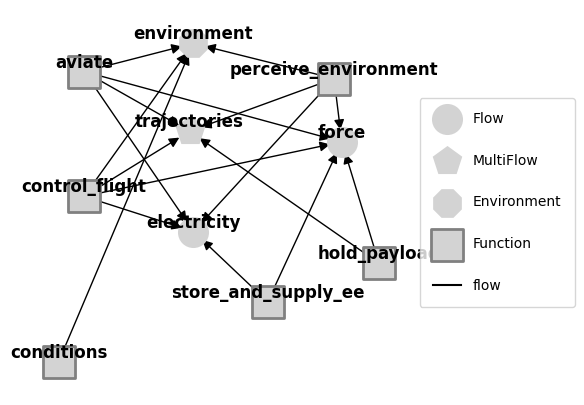

In [3]:
fg = FunctionArchitectureGraph(ha)
pos = {'hurricaneaircraftarchitecture.flows.force': [0.53, 0.25],
       'hurricaneaircraftarchitecture.flows.electricity': [-0.23, -0.26],
       'hurricaneaircraftarchitecture.flows.trajectories': [-0.25, 0.31],
       'hurricaneaircraftarchitecture.flows.environment': [-0.23, 0.81],
       'hurricaneaircraftarchitecture.fxns.control_flight': [-0.79, -0.06],
       'hurricaneaircraftarchitecture.fxns.aviate': [-0.79, 0.65],
       'hurricaneaircraftarchitecture.fxns.store_and_supply_ee': [0.15, -0.66],
       'hurricaneaircraftarchitecture.fxns.perceive_environment': [0.49, 0.61],
       'hurricaneaircraftarchitecture.fxns.hold_payload': [0.72, -0.44]}
fg.set_edge_labels(title='')
fg.set_pos(**pos)
fig, ax = fg.draw(figsize=(5,5))
fig.savefig("hac_arch.pdf",  bbox_inches='tight')

In [4]:
# %matplotlib qt5
# fg.move_nodes()
# %matplotlib inline

## Environment

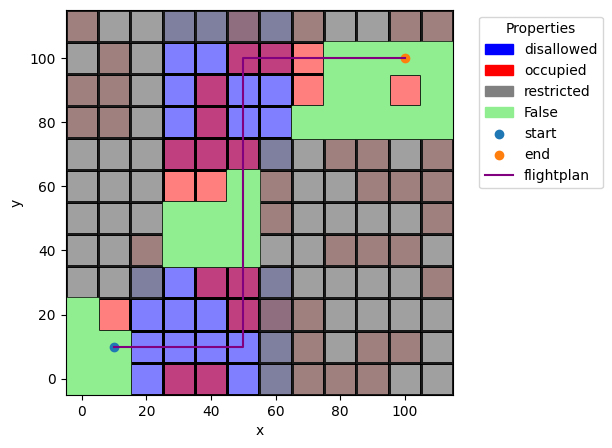

In [5]:
from aerialdrm.hurricane.hurricaneenvironment import properties, collections
from fmdtools.analyze.common import consolidate_legend
fig, ax = ha.flows['environment'].c.show(properties=properties, collections=collections)
ax.scatter([10], [10], label="start")
ax.scatter([100], [100], label="end")
xs = [x[0] for x in ha.p.flightplan]
ys = [x[1] for x in ha.p.flightplan]
ax.plot(xs, ys, label="flightplan", color="purple")
consolidate_legend(ax)

## Simulation

In [6]:
from fmdtools.sim import propagate
res, hist = propagate.nominal(ha)

res

endclass: 
--faultmodes:                      set()
--unsuitable_landing:              False
--disallowed_landing:              False
--occupied_landing:                False
--restricted_landing:              False
--restricted_flight:               False
--mission_complete:                 True
--landing_damage:                  False
--crash:                           False

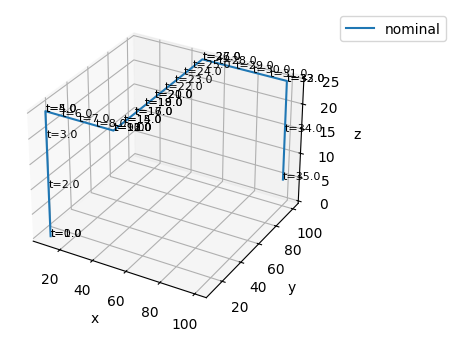

In [7]:
fig, ax = hist.plot_trajectories('trajectories.s.x',
                                 'trajectories.s.y',
                                 'trajectories.s.z',
                                  time_groups='nominal', time_ticks=1.0)

## Fault Scenarios

### Loss of Control

In [8]:
res, hist = propagate.one_fault(ha, 'control_flight', 'loss', 9, desired_result=['endclass', 'graph'])
res

endclass.faultmodes: {'store_and_supply_ee.break', 'control_flight.loss', 'aviate.crash', 'hold_payload.break', 'perceive_environment.break'}
endclass.unsuitable_landing:        True
endclass.disallowed_landing:        True
endclass.occupied_landing:         False
endclass.restricted_landing:        True
endclass.restricted_flight:         True
endclass.mission_complete:         False
endclass.landing_damage:            True
endclass.crash:                     True
graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x000001E50B77E090>

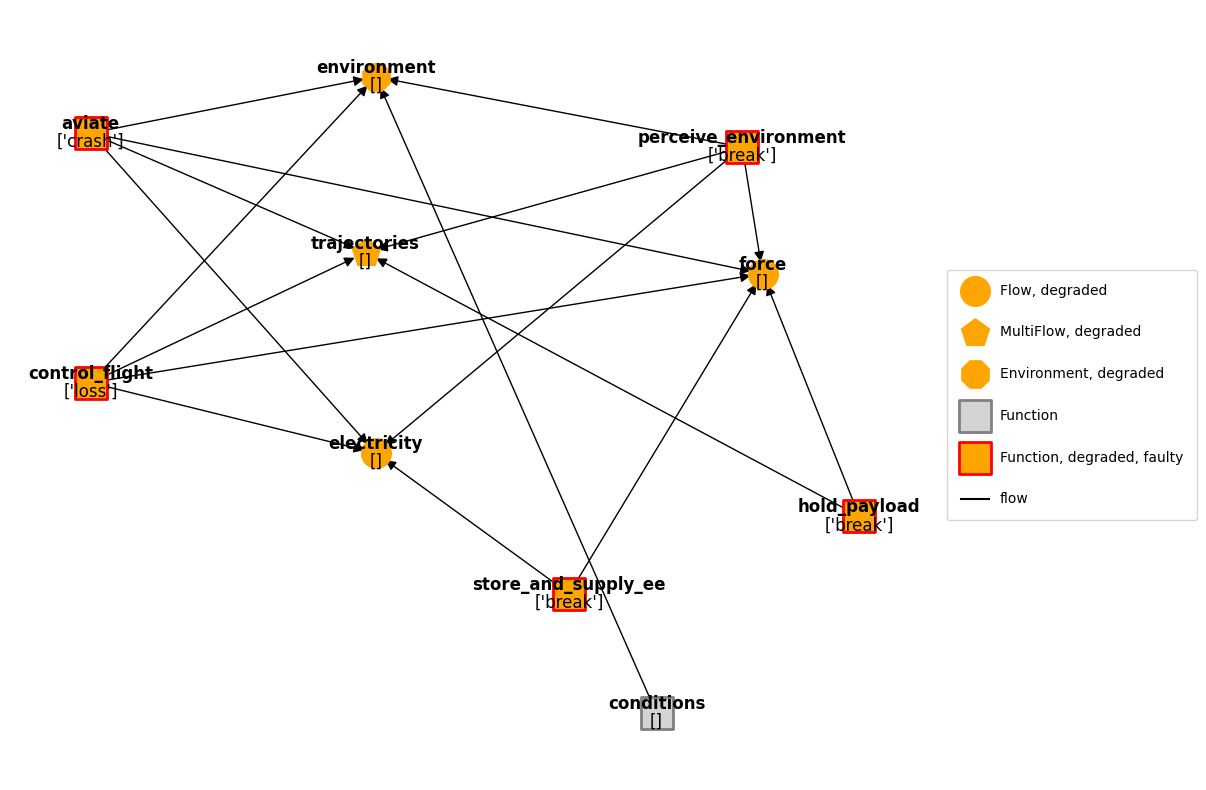

In [9]:
res.graph.set_pos(**pos)
res.graph.set_node_labels(title='shortname', subtext='faults_and_indicators')
res.graph.set_edge_labels(title='')
fig, ax = res.graph.draw()
fig.savefig('arch_no_con.pdf')

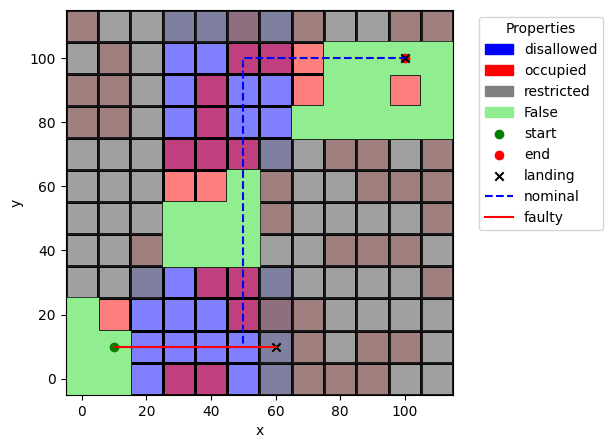

In [10]:
fig, ax = plot_flightpath(ha, hist)
fig.savefig('traj_no_con.pdf')

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

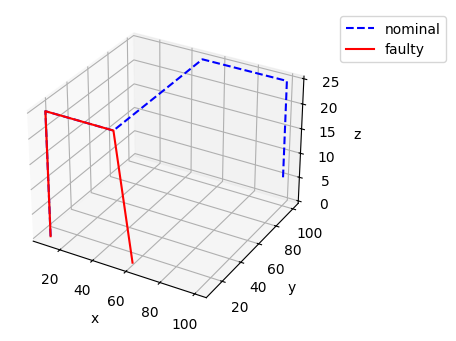

In [11]:
hist.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

### Battery Depletion

In [12]:
ha = HurricaneAircraftArchitecture(p={'depletion': 16.0})
res, hist = propagate.one_fault(ha, 'store_and_supply_ee', 'depletion', 16, desired_result=['endclass', 'graph'])

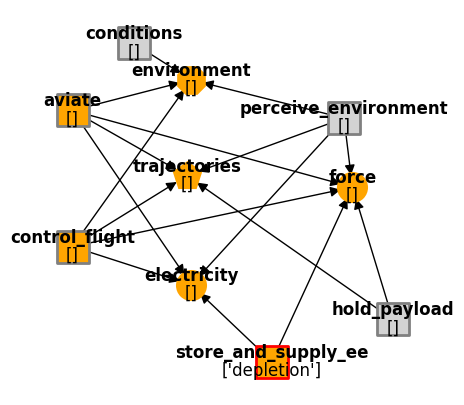

In [13]:
res.graph.set_pos(**pos)
res.graph.set_node_labels(title='shortname', subtext='faults_and_indicators')
res.graph.set_edge_labels(title='')
fig, ax = res.graph.draw(figsize=(5,5), withlegend=False)
fig.savefig('arch_bat_depletion.pdf',  bbox_inches='tight')

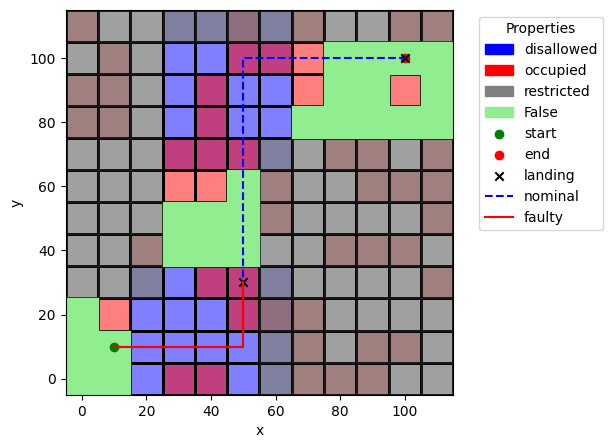

In [14]:
fig, ax = plot_flightpath(ha, hist)
fig.savefig('traj_bat_depletion.pdf')

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

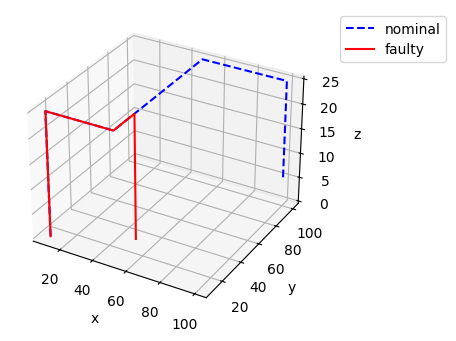

In [15]:
hist.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

## Statistical Simulation


Standard/25% depletion:

In [16]:
from fmdtools.analyze.phases import from_hist
pms = from_hist(hist.nominal)
pm = pms['store_and_supply_ee']

In [17]:
from fmdtools.sim.sample import FaultDomain, FaultSample

ha_25 = HurricaneAircraftArchitecture()
fd = FaultDomain(ha_25)
fd.add_fault('store_and_supply_ee', 'depletion')

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use', method='all')
fs

FaultSample of scenarios: 
 - store_and_supply_ee_depletion_t0p0
 - store_and_supply_ee_depletion_t2p0
 - store_and_supply_ee_depletion_t3p0
 - store_and_supply_ee_depletion_t4p0
 - store_and_supply_ee_depletion_t5p0
 - store_and_supply_ee_depletion_t6p0
 - store_and_supply_ee_depletion_t7p0
 - store_and_supply_ee_depletion_t8p0
 - store_and_supply_ee_depletion_t9p0
 - store_and_supply_ee_depletion_t10p0
 - ... (35 total)

In [18]:
res_25, hist_25 = propagate.fault_sample(ha_25, fs)

SCENARIOS COMPLETE: 100%|██████████| 35/35 [00:04<00:00,  8.42it/s]


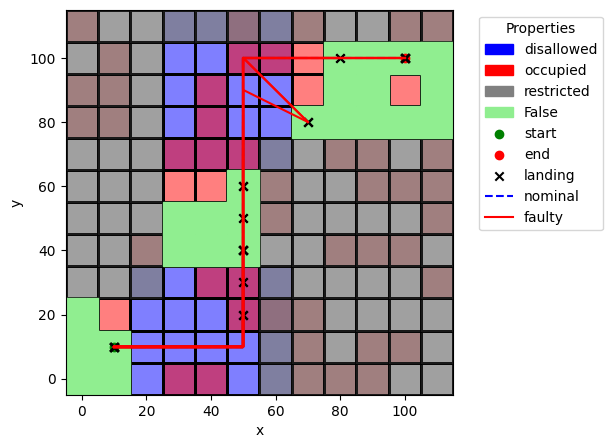

In [19]:
fig, ax = plot_flightpath(ha_25, hist_25)

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

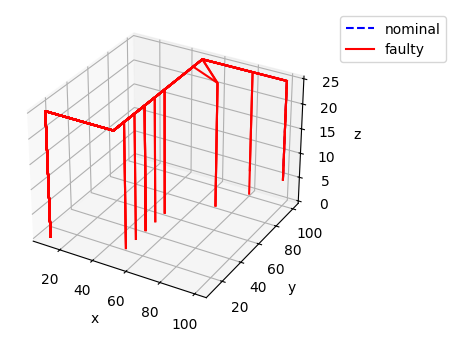

In [20]:
hist_25.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

16% depletion

In [21]:
ha_16 = HurricaneAircraftArchitecture(p={'depletion': 18.0})
fd = FaultDomain(ha_16)
fd.add_fault('store_and_supply_ee', 'depletion')

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use', method='all')
fs
res_16, hist_16 = propagate.fault_sample(ha_16, fs)

SCENARIOS COMPLETE: 100%|██████████| 35/35 [00:04<00:00,  8.75it/s]


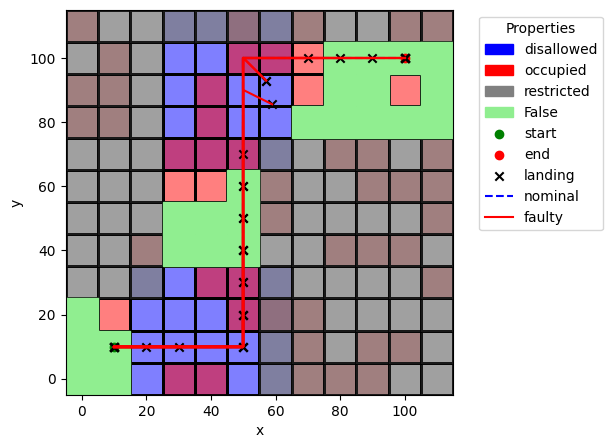

In [22]:
fig, ax = plot_flightpath(ha_16, hist_16)
fig.savefig('depletion_flightpath16.pdf',  bbox_inches='tight')

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

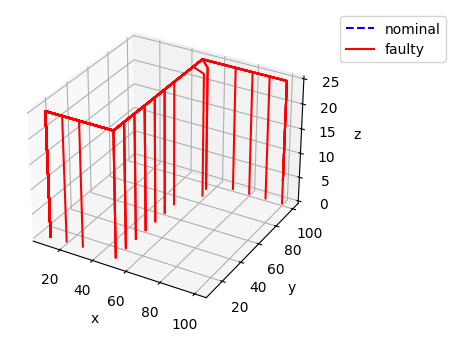

In [23]:
hist_16.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

0% depletion

In [24]:
ha_0 = HurricaneAircraftArchitecture(p={'depletion': 0.0})
fd = FaultDomain(ha_0)
fd.add_fault('store_and_supply_ee', 'depletion')

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use', method='all')
fs
res_0, hist_0 = propagate.fault_sample(ha_0, fs)

SCENARIOS COMPLETE: 100%|██████████| 35/35 [00:03<00:00,  9.31it/s]


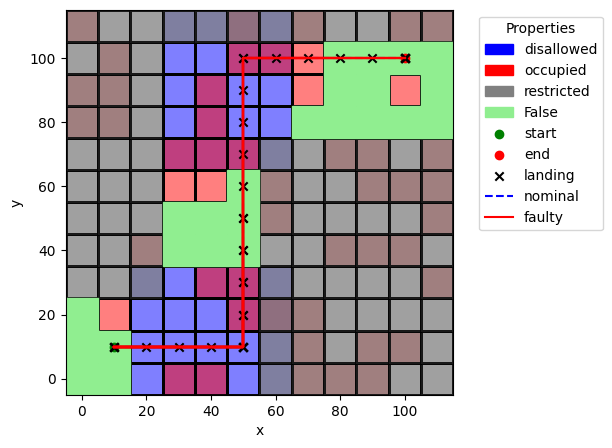

In [25]:
fig, ax = plot_flightpath(ha_0, hist_0)

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

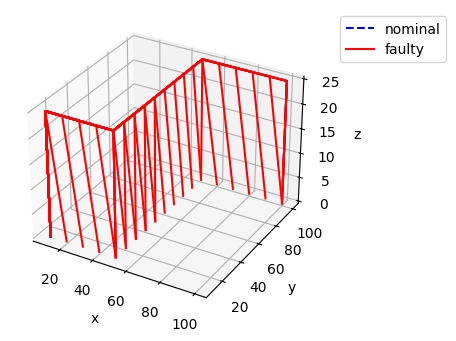

In [26]:
hist_0.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

In [27]:
from fmdtools.analyze.tabulate import FMEA, result_summary_fmea, Comparison
fm = FMEA(res_0, fs, percent_metric=['mission_complete', 'unsuitable_landing', 'disallowed_landing', 'occupied_landing', 'landing_damage', 'crash'])
fm0 = fm.as_table()
fm0 = fm0.rename(index={'store_and_supply_ee': ''})
fm0 = fm0.rename(index={'depletion': 'depletion (0\%)'})
fm0

,,percent_mission_complete,percent_unsuitable_landing,percent_disallowed_landing,percent_occupied_landing,percent_landing_damage,percent_crash
,depletion (0\%),0.142857,0.542857,0.514286,0.257143,0.885714,0.885714


In [28]:
fm = FMEA(res_16, fs, percent_metric=['mission_complete', 'unsuitable_landing', 'disallowed_landing', 'occupied_landing', 'landing_damage', 'crash'])
fm16 = fm.as_table()
fm16 = fm16.rename(index={'store_and_supply_ee': ''})
fm16 = fm16.rename(index={'depletion': 'depletion (16\%)'})
fm16

,,percent_mission_complete,percent_unsuitable_landing,percent_disallowed_landing,percent_occupied_landing,percent_landing_damage,percent_crash
,depletion (16\%),0.142857,0.428571,0.4,0.2,0.0,0.0


In [29]:
fm = FMEA(res_25, fs, percent_metric=['mission_complete', 'unsuitable_landing', 'disallowed_landing', 'occupied_landing', 'landing_damage', 'crash'])
fm25 = fm.as_table()
fm25 = fm25.rename(index={'store_and_supply_ee': ''})
fm25 = fm25.rename(index={'depletion': 'depletion (25\%)'})
fm25

,,percent_mission_complete,percent_unsuitable_landing,percent_disallowed_landing,percent_occupied_landing,percent_landing_damage,percent_crash
,depletion (25\%),0.171429,0.142857,0.142857,0.142857,0.0,0.0


In [30]:
import pandas as pd
full_fm = pd.concat([fm0, fm16, fm25])
full_fm = full_fm*100
full_fm = full_fm.rename(columns = {'percent_mission_complete': 'mission complete',
                                    'percent_unsuitable_landing': 'unsuitable site',
                                    'percent_disallowed_landing': 'disallowed site',
                                    'percent_occupied_landing': 'occupied site',
                                    'percent_landing_damage': 'damaged',
                                    'percent_crash': 'crashed'})
full_fm = full_fm.style.format(precision=1)
full_fm

In [31]:
print(full_fm.to_latex())

\begin{tabular}{llrrrrrr}
 &  & mission complete & unsuitable site & disallowed site & occupied site & damaged & crashed \\
\multirow[c]{3}{*}{} & depletion (0\%) & 14.3 & 54.3 & 51.4 & 25.7 & 88.6 & 88.6 \\
 & depletion (16\%) & 14.3 & 42.9 & 40.0 & 20.0 & 0.0 & 0.0 \\
 & depletion (25\%) & 17.1 & 14.3 & 14.3 & 14.3 & 0.0 & 0.0 \\
\end{tabular}



## Statistical Simulation - New

In [32]:
from fmdtools.analyze.phases import from_hist
from fmdtools.sim import propagate
from fmdtools.sim.sample import FaultDomain, FaultSample

ha = HurricaneAircraftArchitecture()
res, hist = propagate.nominal(ha)
pms = from_hist(hist)
pm = pms['store_and_supply_ee']


fd = FaultDomain(ha)
fd.add_fault('store_and_supply_ee', 'depletion', '1', disturbances=(('electricity.s.charge', 1.0), ))
fd.add_fault('store_and_supply_ee', 'depletion', '10', disturbances=(('electricity.s.charge', 10.0), ))
fd.add_fault('store_and_supply_ee', 'depletion', '25', disturbances=(('electricity.s.charge', 25.0), ))

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use', method='all')
fs

res, hist = propagate.fault_sample(ha, fs)

SCENARIOS COMPLETE: 100%|██████████| 105/105 [00:11<00:00,  9.11it/s]


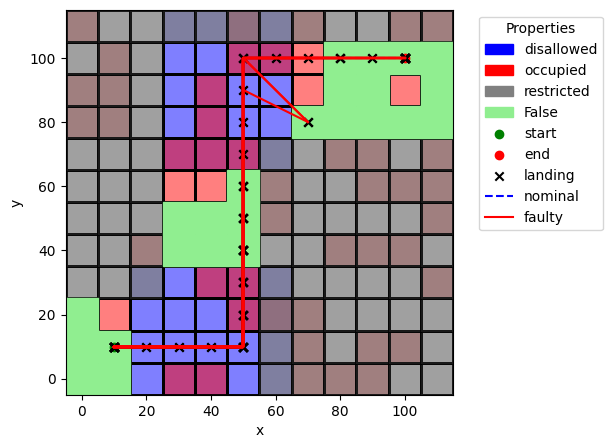

In [33]:
fig, ax = plot_flightpath(ha, hist)